In [1]:
import matplotlib.pyplot as plt

In [2]:
x = [1, 2, 3, 4, 3, 4, 2, 4]



In [5]:
dir(plt)

['AbstractContextManager',
 'Annotation',
 'Arrow',
 'Artist',
 'AutoLocator',
 'AxLine',
 'Axes',
 'BackendFilter',
 'Button',
 'Circle',
 'Colorizer',
 'ColorizingArtist',
 'Colormap',
 'Enum',
 'ExitStack',
 'Figure',
 'FigureBase',
 'FigureCanvasBase',
 'FigureManagerBase',
 'FixedFormatter',
 'FixedLocator',
 'FormatStrFormatter',
 'Formatter',
 'FuncFormatter',
 'GridSpec',
 'IndexLocator',
 'Line2D',
 'LinearLocator',
 'Locator',
 'LogFormatter',
 'LogFormatterExponent',
 'LogFormatterMathtext',
 'LogLocator',
 'MaxNLocator',
 'MouseButton',
 'MultipleLocator',
 'Normalize',
 'NullFormatter',
 'NullLocator',
 'PolarAxes',
 'Polygon',
 'Rectangle',
 'ScalarFormatter',
 'Slider',
 'Subplot',
 'SubplotSpec',
 'TYPE_CHECKING',
 'Text',
 'TickHelper',
 'Widget',
 '_ColorizerInterface',
 '_NO_PYPLOT_NOTE',
 '_REPL_DISPLAYHOOK',
 '_ReplDisplayHook',
 '__annotations__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_a

(array([1., 2., 2., 3.]),
 array([1.  , 1.75, 2.5 , 3.25, 4.  ]),
 <BarContainer object of 4 artists>)

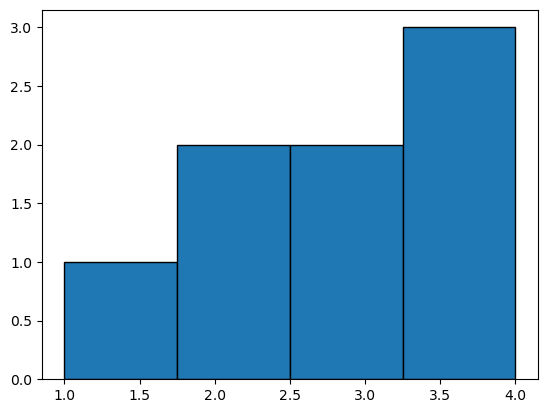

In [4]:
plt.hist(x, bins=4, edgecolor='black')

In [ ]:
%pip -q install cartopy xarray netcdf4

Note: you may need to restart the kernel to use updated packages.


In [16]:
%pip install h5netcdf

Note: you may need to restart the kernel to use updated packages.


In [22]:
%pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [24]:

import zipfile, io
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# --- Load ERA5 data ---
zip_path = '/home/chantelle/Desktop/PhD Project/code/openfast/era5_out/era5_sl_1950_01.nc'
with zipfile.ZipFile(zip_path) as zf:
    with zf.open('data_stream-oper_stepType-instant.nc') as f:
        ds = xr.open_dataset(io.BytesIO(f.read()), engine='h5netcdf')

# --- Compute mean wind speed at 100m ---
ws100 = np.sqrt(ds['u100']**2 + ds['v100']**2).mean('valid_time')

# --- Plot ---
fig, ax = plt.subplots(
    figsize=(10, 7),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

mesh = ax.pcolormesh(
    ws100.longitude, ws100.latitude, ws100,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    shading='auto'
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle='--')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle=':')
gl.top_labels = False
gl.right_labels = False

plt.colorbar(mesh, ax=ax, label='Mean wind speed at 100m (m/s)', shrink=0.8)
ax.set_title('ERA5 mean 100m wind speed — January 1950')
plt.tight_layout()
plt.show()


ImportError: No module named 'h5py', backend not available. Please install 'h5py' into your Python environment.

In [1]:
!pip list

Package                   Version
------------------------- ---------------
aiofiles                  24.1.0
annotated-doc             0.0.4
annotated-types           0.7.0
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     25.4.0
audioop-lts               0.2.2
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
brotli                    1.2.0
Cartopy                   0.25.0
cdsapi                    0.7.7
certifi                   2026.2.25
cffi                      2.0.0
cftime                    1.6.5
charset-normalizer        3.4.5
click                     8.3.1
comm                      0.2.3
contourpy                 1.3.3
control                   0.10.2
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
deepdiff     

NameError: name 'openfast_io' is not defined

In [4]:
import openfast_io
dir(openfast_io)

['__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__']

In [5]:
?openfast_io

Type:        module
String form: <module 'openfast_io' (namespace) from ['/home/chantelle/miniconda3/envs/openfast_env/lib/python3.13/site-packages/openfast_io']>
Docstring:   <no docstring>

In [6]:
from openfast_io import FAST_reader

In [8]:
dir(FAST_reader)

['FstOutput',
 'InputReader_OpenFAST',
 'ROSCO',
 'ROSCO_turbine',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'bool_read',
 'copy',
 'fix_path',
 'float_read',
 'int_read',
 'load_ascii_output',
 'load_from_txt',
 'np',
 'operator',
 'os',
 'quoted_read',
 're',
 'read_DISCON',
 'read_array',
 'readline_filterComments',
 'readline_ignoreComments',
 'reduce']

In [ ]:
FAST_reader.FstOutput(IEA-15-240-RWT/OpenFAST/IEA-15-240-RWT-Monopile/IEA-15-240-RWT-Monopile.outb)

TypeError: 'dict' object is not callable

In [22]:
FAST_reader.InputReader_OpenFAST?

Init signature: FAST_reader.InputReader_OpenFAST()
Docstring:      OpenFAST input file reader 
File:           ~/miniconda3/envs/openfast_env/lib/python3.13/site-packages/openfast_io/FAST_reader.py
Type:           type
Subclasses:     

In [13]:
!pip install fast_io

This process (pid=355451) is multi-threaded, use of forkpty() may lead to deadlocks in the child.

In [16]:
!pip list

This process (pid=355451) is multi-threaded, use of forkpty() may lead to deadlocks in the child.

Package                   Version
------------------------- ---------------
aiofiles                  24.1.0
annotated-doc             0.0.4
annotated-types           0.7.0
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     25.4.0
audioop-lts               0.2.2
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
brotli                    1.2.0
Cartopy                   0.25.0
cdsapi                    0.7.7
certifi                   2026.2.25
cffi                      2.0.0
cftime                    1.6.5
charset-normalizer        3.4.5
click                     8.3.1
comm                      0.2.3
contourpy                 1.3.3
control                   0.10.2
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
deepdiff     

In [17]:
pip install OpenFastSEES

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.5/868.5 kB 17.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 MB 23.2 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [OpenFastSEES] [OpenFastSEES]ux]
Note: you may need to restart the kernel to use updated packages.


In [19]:
import openseespy

In [20]:
dir(openseespy)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__']

In [21]:
import OpenFastSEES as opfs
dir(opfs)

ModuleNotFoundError: No module named 'OpenFastSEES'

In [ ]:
"""
07_openfast_outputs
-------------------
Demonstrate the ROSCO routines for reading OpenFAST I/O files.
Nearly all the figures in the example documentation rely on a version of these scripts, which can also be used to load ROSCO *.dbg* files, including

 # .dbg files output basic ROSCO internal variables, like the inputs and outputs to the wind speed estimator
 # .dbg2 files output all the ROSCO LocalVariables.  If the variable is an array, only the first entry is recorded.
 # .dbg3 files output the avrSWAP array at each timestep that is transfered between ROSCO and the multi-physics solver

Note: this example relies on the previous running of the OpenFAST model in 'Test_Cases/NREL-5MW/' to plot.
"""

# Python Modules
#import numpy as np
import matplotlib.pyplot as plt 
# ROSCO toolbox modules 
from rosco.toolbox.ofTools.fast_io import output_processing
import os

def main():
    this_dir = os.path.dirname(os.path.abspath(__file__))
    example_out_dir = os.path.join(this_dir,'examples_out')
    if not os.path.isdir(example_out_dir):
        os.makedirs(example_out_dir)

    # Define openfast output filenames
    filenames = ["Test_Cases/IEA-15-240-RWT/IEA-15-240-RWT-UMaineSemi/IEA-15-240-RWT-UMaineSemi.outb"]
    # ---- Note: Could load and plot multiple cases, textfiles, and binaries...
    # filenames = ["../Test_Cases/NREL-5MW/NREL-5MW.outb",
    #             "../Test_Cases/NREL-5MW/NREL-5MW_ex8.outb"]

    filenames = [os.path.join(this_dir,file) for file in filenames]

    #  Define Plot cases 
    #  --- Comment,uncomment, create, and change these as desired...
    cases = {}
    cases['Baseline'] = ['Wind1VelX', 'BldPitch1', 'GenTq', 'RotSpeed']
    # cases['Rotor'] = ['BldPitch1', 'GenTq', 'GenPwr']
    # cases['Platform Motion'] = ['PtfmSurge', 'PtfmSway', 'PtfmHeave', 'PtfmPitch','PtfmRoll','PtfmYaw']


    # Instantiate fast_IO
    fast_out = output_processing.output_processing()
    # Can also do:
    # fast_out = output_processing.output_processing(filenames=filenames, cases=cases)
    # fast_out.plot_fast_out()

    # Load and plot
    fastout = fast_out.load_fast_out(filenames)
    fast_out.plot_fast_out(cases=cases,showplot=False)

    plt.savefig(os.path.join(example_out_dir,'07_IEA-15MW_Semi_Out.png'))

if __name__ == "__main__":
    main()


([<Figure size 640x480 with 6 Axes>],
 [array([<Axes: title={'center': 'Baseline'}, ylabel='Wind1VelX \n (m/s)'>,
         <Axes: ylabel='BldPitch1 \n (deg)'>,
         <Axes: ylabel='GenTq \n (kN-m)'>,
         <Axes: ylabel='RotSpeed \n (rpm)'>,
         <Axes: ylabel='PtfmSway \n (m)'>,
         <Axes: ylabel='PtfmYaw \n (deg)'>], dtype=object)])

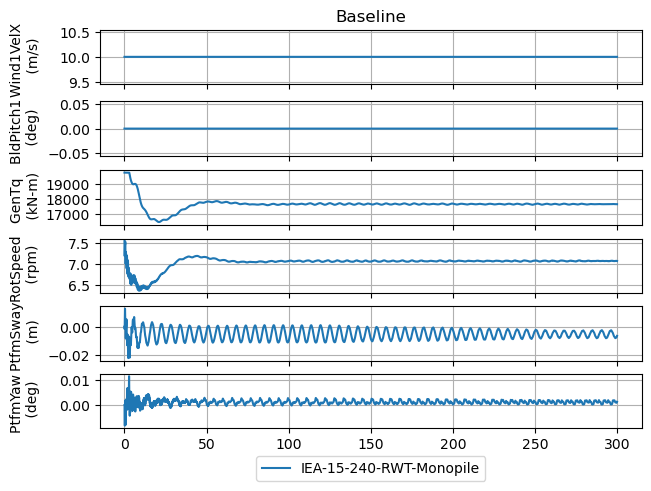

In [43]:
# Python Modules
#import numpy as np
import matplotlib.pyplot as plt 
# ROSCO toolbox modules 
from rosco.toolbox.ofTools.fast_io import output_processing
import os

this_dir = os.path.dirname(os.path.abspath('./openfast'))
example_out_dir = os.path.join(this_dir,'examples_out')
if not os.path.isdir(example_out_dir):
    os.makedirs(example_out_dir)

# Define openfast output filenames
filenames = ["IEA-15-240-RWT/OpenFAST/IEA-15-240-RWT-Monopile/IEA-15-240-RWT-Monopile.outb"]
# ---- Note: Could load and plot multiple cases, textfiles, and binaries...
# filenames = ["../Test_Cases/NREL-5MW/NREL-5MW.outb",
#             "../Test_Cases/NREL-5MW/NREL-5MW_ex8.outb"]

filenames = [os.path.join(this_dir,file) for file in filenames]

#  Define Plot cases 
#  --- Comment,uncomment, create, and change these as desired...
cases = {}
cases['Baseline'] = ['Wind1VelX', 'BldPitch1', 'GenTq', 'RotSpeed','PtfmSway', 'PtfmYaw']
# cases['Rotor'] = ['BldPitch1', 'GenTq', 'GenPwr']
# cases['Platform Motion'] = ['PtfmSurge', 'PtfmSway', 'PtfmHeave', 'PtfmPitch','PtfmRoll','PtfmYaw']


# Instantiate fast_IO
fast_out = output_processing.output_processing()
# Can also do:
# fast_out = output_processing.output_processing(filenames=filenames, cases=cases)
# fast_out.plot_fast_out()

# Load and plot
fastout = fast_out.load_fast_out(filenames)
# fastout
fast_out.plot_fast_out(cases=cases,showplot=False)

# plt.savefig(os.path.join(example_out_dir,'07_IEA-15MW_Semi_Out.png'))


In [32]:
import pandas as pd

In [33]:
len(fastout[0].keys())

keys_chosen = ['Wind1VelX', 'BldPitch1', 'GenTq', 'RotSpeed']

fast_df = pd.DataFrame({key: fastout[0][key] for key in keys_chosen})

In [34]:
fast_df

,Wind1VelX,BldPitch1,GenTq,RotSpeed
0,10.0,0.0,19786.800366,7.550001
1,10.0,0.0,19786.800366,7.517114
2,10.0,0.0,19786.800366,7.485447
3,10.0,0.0,19786.800366,7.454838
4,10.0,0.0,19786.800366,7.426275
...,...,...,...,...
59996,10.0,0.0,17656.873262,7.076091
59997,10.0,0.0,17656.873262,7.076144
59998,10.0,0.0,17656.924118,7.076216
59999,10.0,0.0,17656.924118,7.076288


In [37]:
!pip install seaborn
import seaborn as sns


This process (pid=355451) is multi-threaded, use of forkpty() may lead to deadlocks in the child.

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


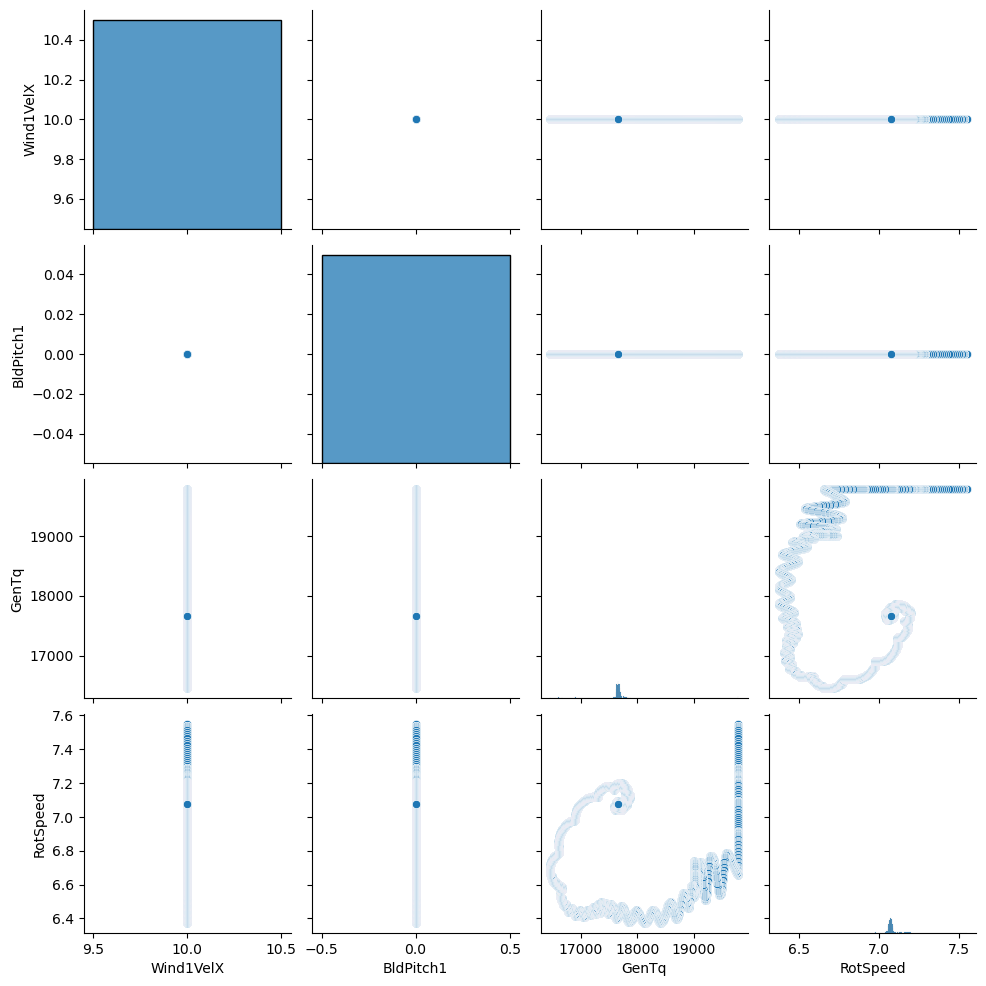

In [ ]:
sns.pairplot(fast_df);